In [1]:
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

 - https://stackoverflow.com/questions/79720948/solve-a-2-equations-systems-of-quadratic-equations-with-2-unknows

In [2]:
def model(x, a):
    return a[0] + a[1] * x[0] + a[2] * x[1] + a[3] * x[0] * x[1] + a[4] * x[0] ** 2 + a[5] * x[1] ** 2

In [3]:
a1 = [2.210e-04, 6.071e-07, -1.942e-05, 9.131e-08, 1.258e-10, 2.269e-07]
a2 = [-2.658e-04, 4.486e-06, 1.824e-05, 4.013e-07, 1.767e-11, -2.623e-07]

In [4]:
model1 = functools.partial(model, a=a1)
model2 = functools.partial(model, a=a2)

In [5]:
def objective(x, g1, g2):
    return np.array([
        model1(x) - g1,
        model2(x) - g2,
    ])

In [6]:
x0s = np.array([
    [+1000, -100],
    [-1000, -100],
    [+1000, +100]
])

In [7]:
x0s = np.array([
    [+0, +0],
    [+0, +100],
    [+400, +0],
    [+400, +100],
])

In [8]:
def solve(g1=0.0, g2=0.0):
    solutions = []
    for x0 in x0s:
        solution = optimize.root(objective, x0=x0, args=(g1, g2))
        if solution.success:
            solutions.append(solution.x)
        else:
            solutions.append([np.nan] * 2)
    return np.array(solutions)

In [9]:
g1, g2 = objective([400, 30], 0, 0)
g1, g2

(0.0012012979999999997, 0.0066581572)

In [10]:
solutions = solve(g1, g2)
solutions

array([[400.        ,  30.        ],
       [299.29206768,  44.00297654],
       [400.        ,  30.        ],
       [299.29206761,  44.00297655]])

In [11]:
x0lin = np.linspace(np.nanmin(solutions[:,0]) - 20., np.nanmax(solutions[:,0]) + 20., 200)
x1lin = np.linspace(np.nanmin(solutions[:,1]) - 20., np.nanmax(solutions[:,1]) + 20., 200)
X0, X1 = np.meshgrid(x0lin, x1lin)

In [12]:
Z1 = model1([X0, X1])
Z2 = model2([X0, X1])

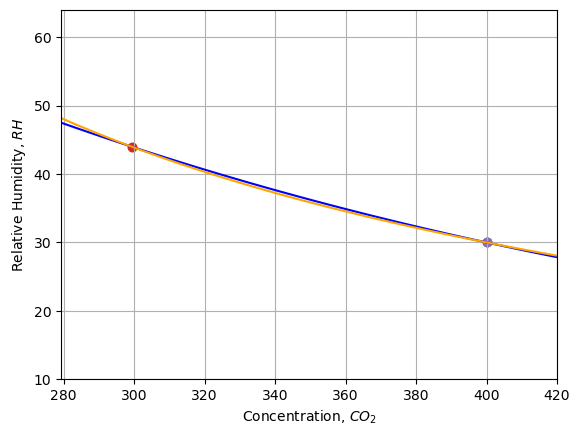

In [13]:
fig, axe = plt.subplots()
axe.contour(X0, X1, Z1, [g1], colors="blue")
axe.contour(X0, X1, Z2, [g2], colors="orange")
for solution in solutions:
    axe.scatter(*solution)
axe.scatter(*solutions[0, :])
axe.set_xlabel("Concentration, $CO_2$")
axe.set_ylabel("Relative Humidity, $RH$")
axe.grid()

In [14]:
g1, g2 = objective([850, 35], 0, 0)
g1, g2

(0.0031426504999999996, 0.015815824075)

In [15]:
solve(g1, g2)

array([[872.21163786,  33.82272003],
       [850.00000003,  35.        ],
       [872.21163786,  33.82272003],
       [849.99999994,  35.        ]])

In [16]:
n = 200
CO2lin = np.linspace(1000, 400, n)
RHlin = np.linspace(20, 80, n)

In [17]:
dataset = pd.DataFrame({"CO2": CO2lin, "%RH": RHlin})

In [18]:
def generator(x):
    signal = objective([x["CO2"], x["%RH"]], 0, 0)
    return pd.Series({
        "g1": signal[0],
        "g2": signal[1],
    })

In [19]:
def solver(x):
    series = {}
    solutions = solve(x["g1"], x["g2"])
    for i, solution in enumerate(solutions):
        series[f"CO2_{i}"] = solution[0]
        series[f"%RH_{i}"] = solution[1]
    return pd.Series(series)

In [20]:
dataset[["g1", "g2"]] = dataset.apply(generator, axis=1)

In [21]:
dataset

,CO2,%RH,g1,g2
0,1000.000000,20.000000,0.002482,0.012524
1,996.984925,20.301508,0.002499,0.012609
2,993.969849,20.603015,0.002515,0.012693
3,990.954774,20.904523,0.002531,0.012777
4,987.939698,21.206030,0.002547,0.012860
...,...,...,...,...
195,412.060302,78.793970,0.003336,0.014424
196,409.045226,79.095477,0.003328,0.014357
197,406.030151,79.396985,0.003320,0.014290
198,403.015075,79.698492,0.003312,0.014222


<Axes: >

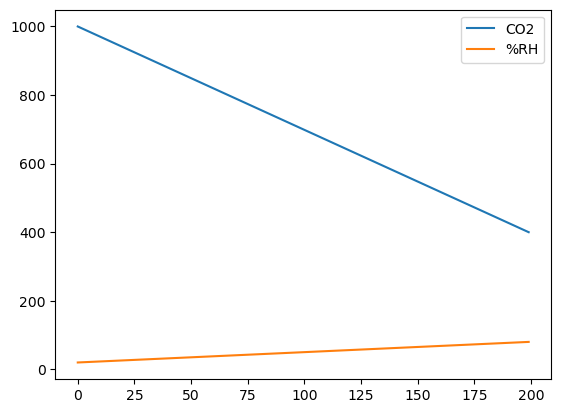

In [22]:
dataset[["CO2", "%RH"]].plot()

<Axes: >

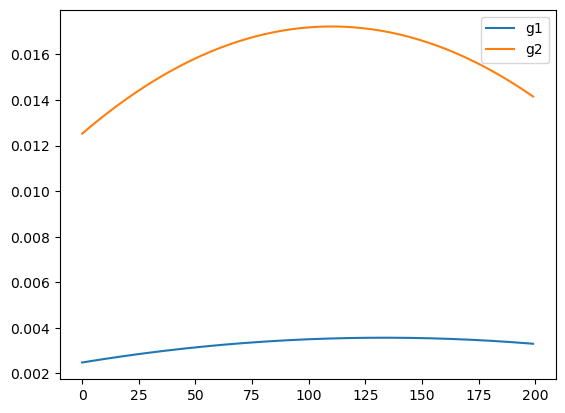

In [23]:
dataset[["g1", "g2"]].plot()

In [24]:
dataset = pd.concat([dataset, dataset.apply(solver, axis=1)], axis=1)
dataset

,CO2,%RH,g1,g2,CO2_0,%RH_0,CO2_1,%RH_1,CO2_2,%RH_2,CO2_3,%RH_3
0,1000.000000,20.000000,0.002482,0.012524,518.520093,48.993604,518.520093,48.993604,1000.000000,20.000000,518.520093,48.993604
1,996.984925,20.301508,0.002499,0.012609,524.627278,48.686089,524.627278,48.686089,996.984925,20.301508,524.627278,48.686089
2,993.969849,20.603015,0.002515,0.012693,530.766639,48.378617,530.766639,48.378617,993.969849,20.603015,530.766639,48.378617
3,990.954774,20.904523,0.002531,0.012777,536.938640,48.071192,536.938640,48.071192,990.954774,20.904523,536.938640,48.071192
4,987.939698,21.206030,0.002547,0.012860,543.143750,47.763815,543.143750,47.763815,987.939698,21.206030,543.143750,47.763815
...,...,...,...,...,...,...,...,...,...,...,...,...
195,412.060302,78.793970,0.003336,0.014424,412.060302,78.793970,412.060302,78.793970,2842.241372,1.550842,412.060302,78.793970
196,409.045226,79.095477,0.003328,0.014357,409.045226,79.095477,409.045226,79.095477,2858.426672,1.421426,409.045226,79.095477
197,406.030151,79.396985,0.003320,0.014290,406.030151,79.396985,406.030151,79.396985,2874.608169,1.292798,406.030151,79.396985
198,403.015075,79.698492,0.003312,0.014222,403.015075,79.698492,403.015075,79.698492,2890.785620,1.164945,403.015075,79.698492


In [25]:
dataset

,CO2,%RH,g1,g2,CO2_0,%RH_0,CO2_1,%RH_1,CO2_2,%RH_2,CO2_3,%RH_3
0,1000.000000,20.000000,0.002482,0.012524,518.520093,48.993604,518.520093,48.993604,1000.000000,20.000000,518.520093,48.993604
1,996.984925,20.301508,0.002499,0.012609,524.627278,48.686089,524.627278,48.686089,996.984925,20.301508,524.627278,48.686089
2,993.969849,20.603015,0.002515,0.012693,530.766639,48.378617,530.766639,48.378617,993.969849,20.603015,530.766639,48.378617
3,990.954774,20.904523,0.002531,0.012777,536.938640,48.071192,536.938640,48.071192,990.954774,20.904523,536.938640,48.071192
4,987.939698,21.206030,0.002547,0.012860,543.143750,47.763815,543.143750,47.763815,987.939698,21.206030,543.143750,47.763815
...,...,...,...,...,...,...,...,...,...,...,...,...
195,412.060302,78.793970,0.003336,0.014424,412.060302,78.793970,412.060302,78.793970,2842.241372,1.550842,412.060302,78.793970
196,409.045226,79.095477,0.003328,0.014357,409.045226,79.095477,409.045226,79.095477,2858.426672,1.421426,409.045226,79.095477
197,406.030151,79.396985,0.003320,0.014290,406.030151,79.396985,406.030151,79.396985,2874.608169,1.292798,406.030151,79.396985
198,403.015075,79.698492,0.003312,0.014222,403.015075,79.698492,403.015075,79.698492,2890.785620,1.164945,403.015075,79.698492


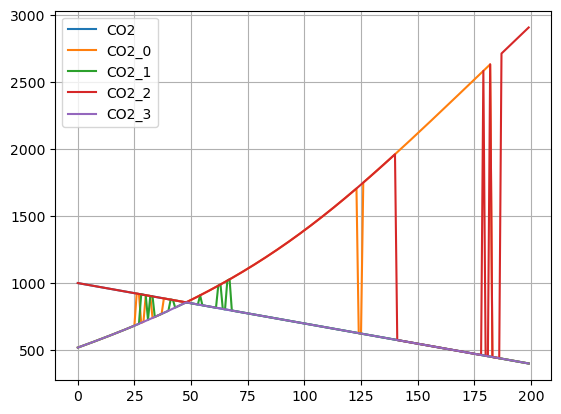

In [26]:
axe = dataset.filter(regex="CO2").plot()
axe.grid()

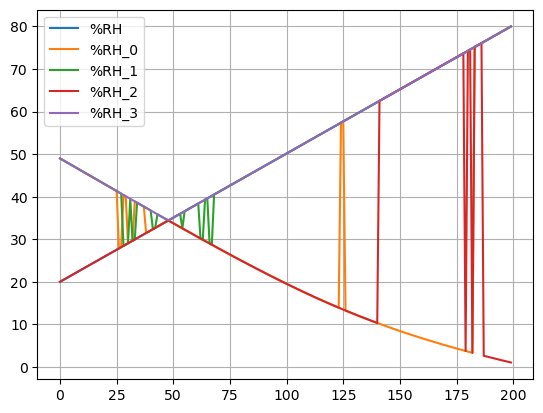

In [27]:
axe = dataset.filter(regex="RH").plot()
axe.grid()

In [28]:
data1 = pd.read_csv("first_signal.csv").drop("Unnamed: 0", axis=1).set_index("time (s)").rename(columns={"Signal (V)": "g1"})
data2 = pd.read_csv("second_signal.csv").drop("Unnamed: 0", axis=1).set_index("time (s)").rename(columns={"Signal (V)": "g2"})

In [29]:
data1.index = pd.to_timedelta(data1.index, unit="s")
data2.index = pd.to_timedelta(data2.index, unit="s")

In [30]:
times = pd.timedelta_range(start=min(data1.index.min(), data2.index.min()), end=max(data1.index.max(), data2.index.max()), freq="250ms")

In [31]:
data1 = data1.reindex(data1.index.union(times)).interpolate(method='time').reindex(times)
data2 = data2.reindex(data2.index.union(times)).interpolate(method='time').reindex(times)

In [32]:
data2.index = data2.index + pd.Timedelta("52s")

In [33]:
data = data1.merge(data2, left_index=True, right_index=True).dropna()

<Axes: >

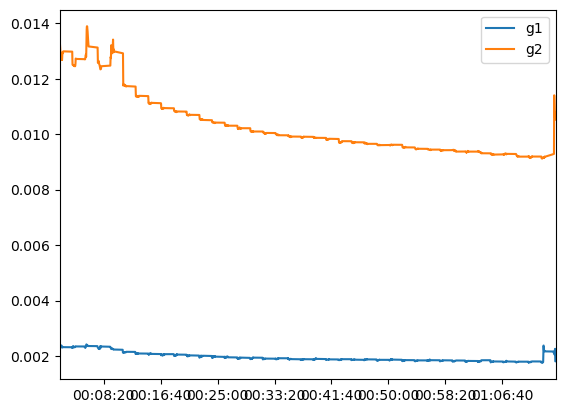

In [34]:
data.plot()

In [35]:
data = data.loc["00:10:30":"00:20:00", :]

<Axes: >

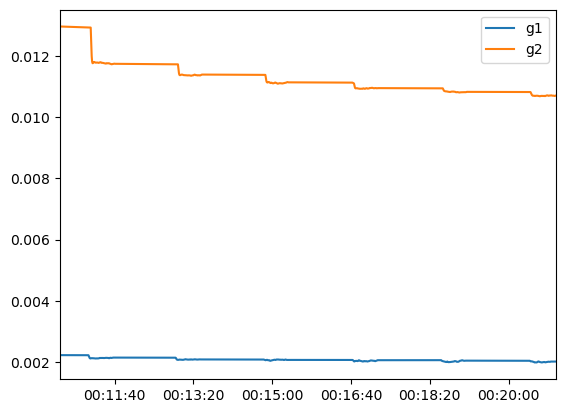

In [36]:
data.plot()

In [37]:
data = data.loc[data["g1"].diff().abs() < 5e-6,:]

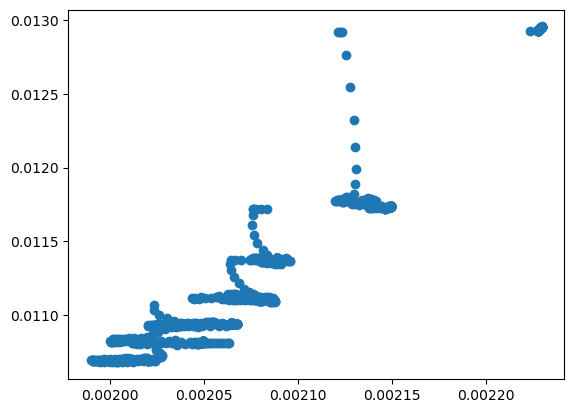

In [38]:
fig, axe = plt.subplots()
axe.scatter(data["g1"], data["g2"])

In [39]:
series = data.apply(solver, axis=1)